# Credit Card Fraud Detection — EDA

Exploratory analysis of the [Kaggle Credit Card Fraud dataset](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud).

284,807 transactions over two days (September 2013, European cardholders).  
Features `V1`–`V28` are PCA-transformed (anonymised); `Amount` and `Time` are raw.  
`Class`: 0 = legitimate, 1 = fraud.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

In [8]:
df = pd.read_csv("../data/raw/creditcard.csv")
print(f"Shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
df.head(3)

Shape: (284807, 31)
Missing values: 0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


## Class Distribution

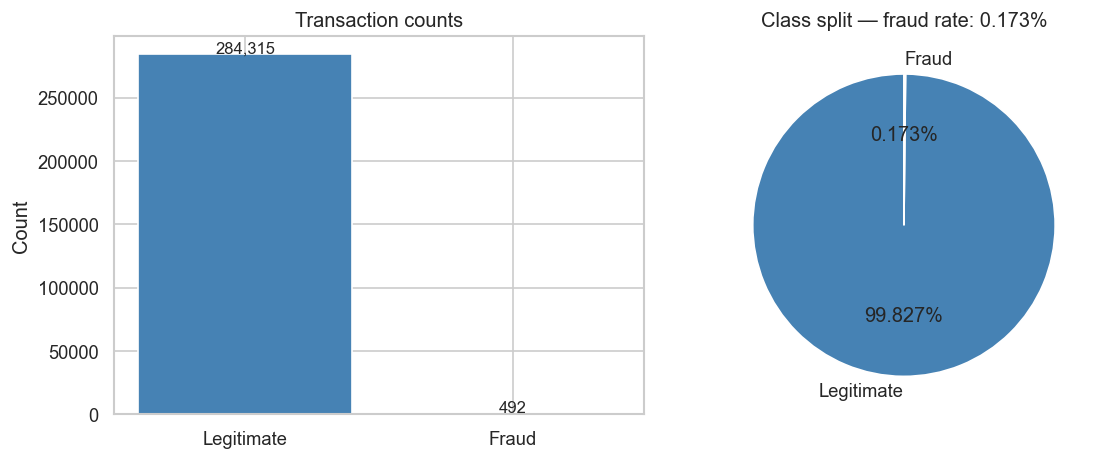

Legitimate: 284,315  |  Fraud: 492


In [9]:
counts = df["Class"].value_counts().sort_index()
fraud_rate = counts[1] / len(df) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(["Legitimate", "Fraud"], counts.values, color=["steelblue", "tomato"], edgecolor="white")
axes[0].set_title("Transaction counts")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1000, f"{v:,}", ha="center", fontsize=10)

axes[1].pie(
    counts.values,
    labels=["Legitimate", "Fraud"],
    colors=["steelblue", "tomato"],
    autopct="%1.3f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white"},
)
axes[1].set_title(f"Class split — fraud rate: {fraud_rate:.3f}%")

plt.tight_layout()
plt.show()
print(f"Legitimate: {counts[0]:,}  |  Fraud: {counts[1]:,}")

## Transaction Amount

C:\Users\bayra\AppData\Local\Temp\ipykernel_31400\2366441099.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


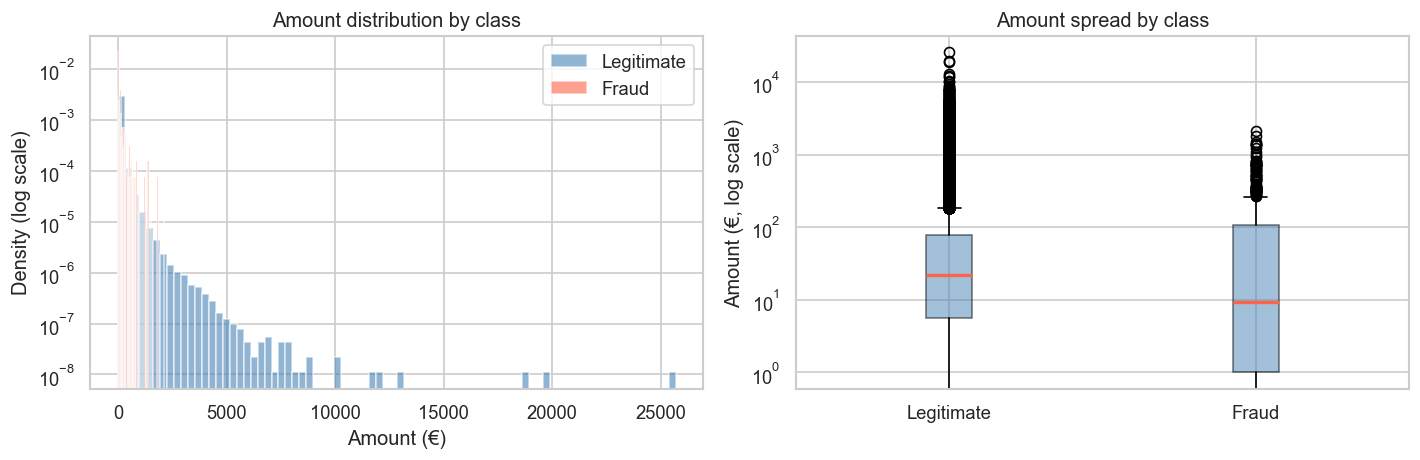

Legitimate — median: €22.00  mean: €88.29  max: €25691.16
Fraud      — median: €9.25  mean: €122.21  max: €2125.87


In [10]:
legit = df[df["Class"] == 0]["Amount"]
fraud = df[df["Class"] == 1]["Amount"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(legit, bins=80, alpha=0.6, label="Legitimate", color="steelblue", density=True)
axes[0].hist(fraud, bins=80, alpha=0.6, label="Fraud", color="tomato", density=True)
axes[0].set_yscale("log")
axes[0].set_xlabel("Amount (€)")
axes[0].set_ylabel("Density (log scale)")
axes[0].set_title("Amount distribution by class")
axes[0].legend()

axes[1].boxplot(
    [legit, fraud],
    labels=["Legitimate", "Fraud"],
    patch_artist=True,
    boxprops=dict(facecolor="steelblue", alpha=0.5),
    medianprops=dict(color="tomato", linewidth=2),
)
axes[1].set_yscale("log")
axes[1].set_ylabel("Amount (€, log scale)")
axes[1].set_title("Amount spread by class")

plt.tight_layout()
plt.show()

print(f"Legitimate — median: €{legit.median():.2f}  mean: €{legit.mean():.2f}  max: €{legit.max():.2f}")
print(f"Fraud      — median: €{fraud.median():.2f}  mean: €{fraud.mean():.2f}  max: €{fraud.max():.2f}")

## Transaction Time

`Time` is seconds since the first transaction (~48 h total). We mod by 24 h to approximate time of day.

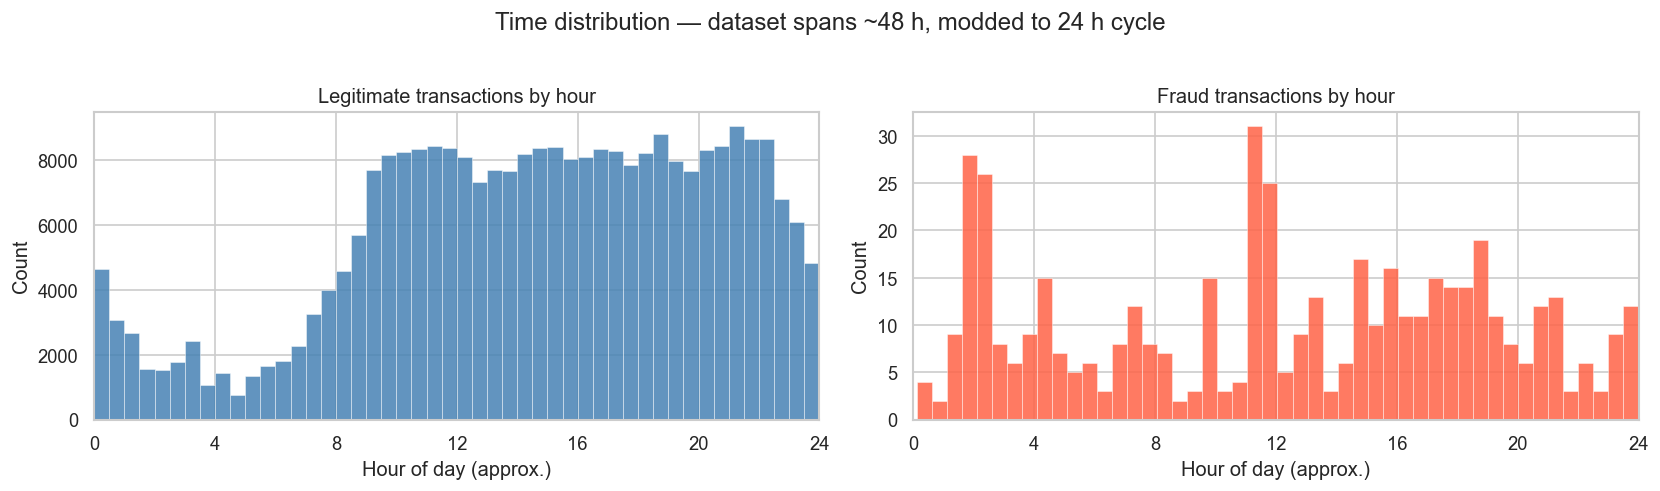

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (label, color, subset) in zip(axes, [
    ("Legitimate", "steelblue", df[df["Class"] == 0]),
    ("Fraud",      "tomato",    df[df["Class"] == 1]),
]):
    hours = (subset["Time"] / 3600) % 24
    ax.hist(hours, bins=48, color=color, alpha=0.85, edgecolor="white", linewidth=0.3)
    ax.set_xlabel("Hour of day (approx.)")
    ax.set_ylabel("Count")
    ax.set_title(f"{label} transactions by hour")
    ax.set_xlim(0, 24)
    ax.set_xticks(range(0, 25, 4))

plt.suptitle("Time distribution — dataset spans ~48 h, modded to 24 h cycle", y=1.02)
plt.tight_layout()
plt.show()

## Feature Separation (V1–V28)

Which PCA components best separate fraud from legitimate transactions?  
We rank by the absolute difference in class means and plot the top 10 as violin plots.

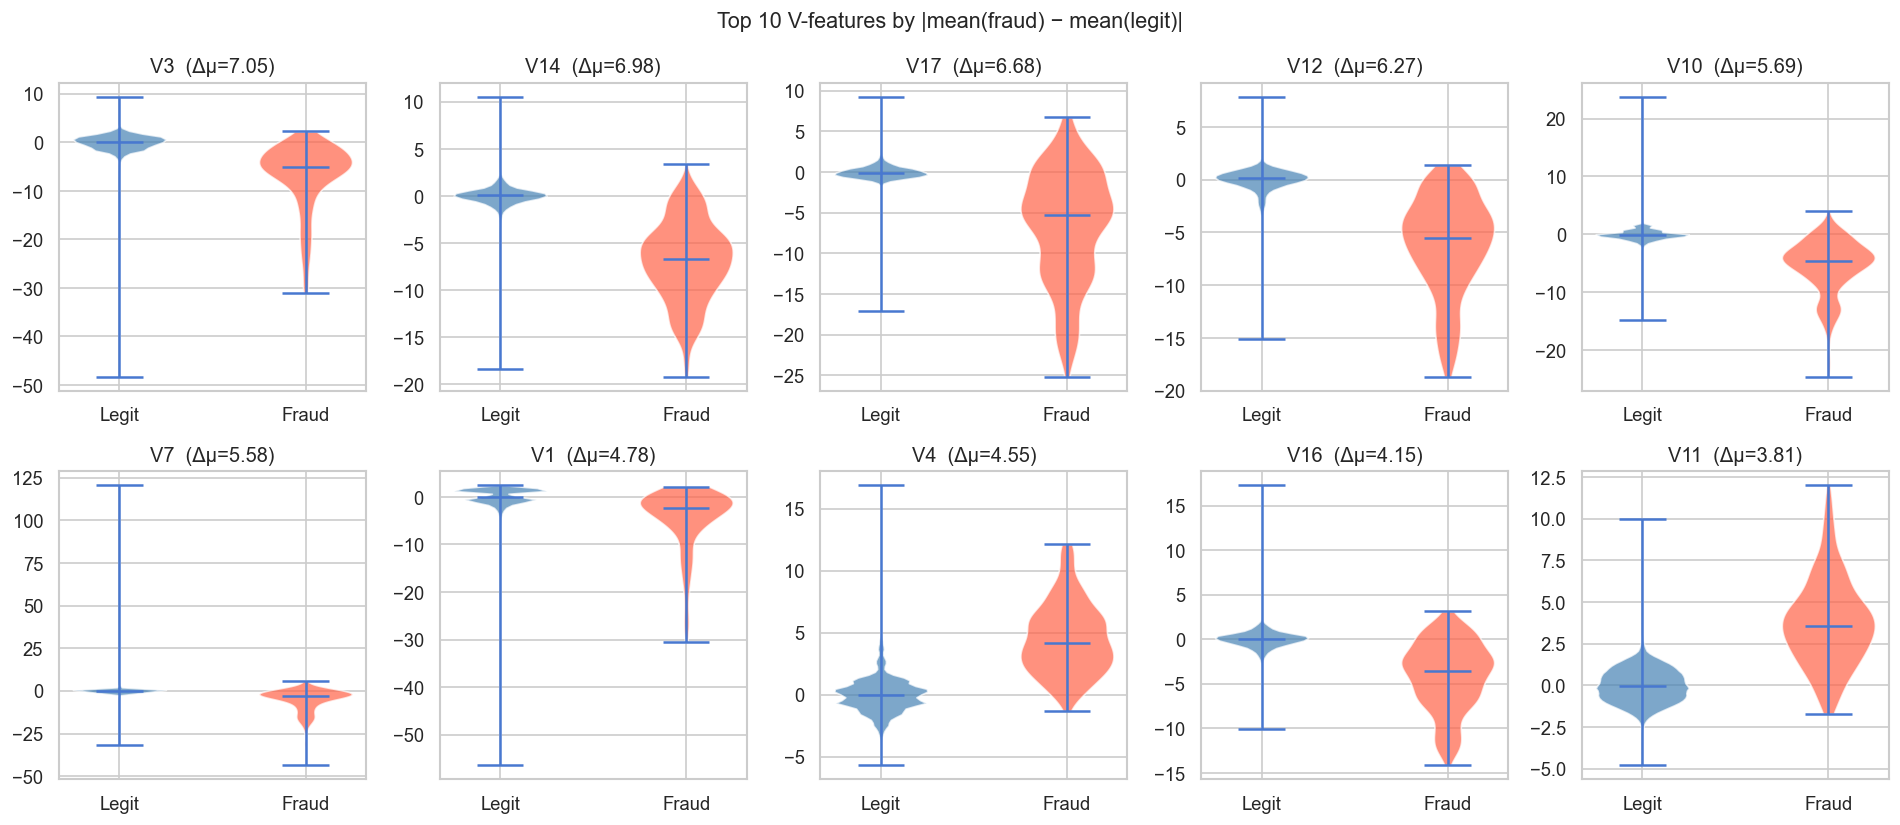

Top 5 most discriminative features:
V3     7.045452
V14    6.983787
V17    6.677371
V12    6.270225
V10    5.686707


In [12]:
v_cols = [c for c in df.columns if c.startswith("V")]
means = df.groupby("Class")[v_cols].mean()
diff = (means.loc[1] - means.loc[0]).abs().sort_values(ascending=False)
top10 = diff.head(10).index.tolist()

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.flatten()

for ax, col in zip(axes, top10):
    parts = ax.violinplot(
        [df.loc[df["Class"] == 0, col], df.loc[df["Class"] == 1, col]],
        showmedians=True,
    )
    parts["bodies"][0].set_facecolor("steelblue")
    parts["bodies"][1].set_facecolor("tomato")
    for b in parts["bodies"]:
        b.set_alpha(0.7)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Legit", "Fraud"])
    ax.set_title(f"{col}  (Δμ={diff[col]:.2f})")

plt.suptitle("Top 10 V-features by |mean(fraud) − mean(legit)|", fontsize=13)
plt.tight_layout()
plt.show()

print("Top 5 most discriminative features:")
print(diff.head(5).to_string())

## Key Takeaways

- **Severe imbalance** (~0.17% fraud) makes accuracy a useless metric — AUC-PR is the right headline.
- **Amount**: fraud transactions cluster at lower amounts on average, but distributions overlap heavily — amount alone is not a reliable signal.
- **Time**: fraud shows a relative uptick during late-night / early-morning hours (~0h–6h), consistent with cardholders being asleep and less likely to notice unusual activity.
- **V-features**: V14, V17, V12, V10 show the largest distributional shift between classes and are the strongest individual signals for an anomaly scorer.
- **Unsupervised framing is justified**: with only 492 labeled fraud examples in the full dataset, an anomaly detection approach trained on legitimate transactions alone is a realistic production constraint.